[Reference](https://medium.com/@Rohan_Dutt/10-seaborn-visualization-techniques-every-data-analyst-should-know-for-enterprise-reporting-4fea8d6cc5d9$0)

# 1. Master Contextual Styling with seaborn.set_context()


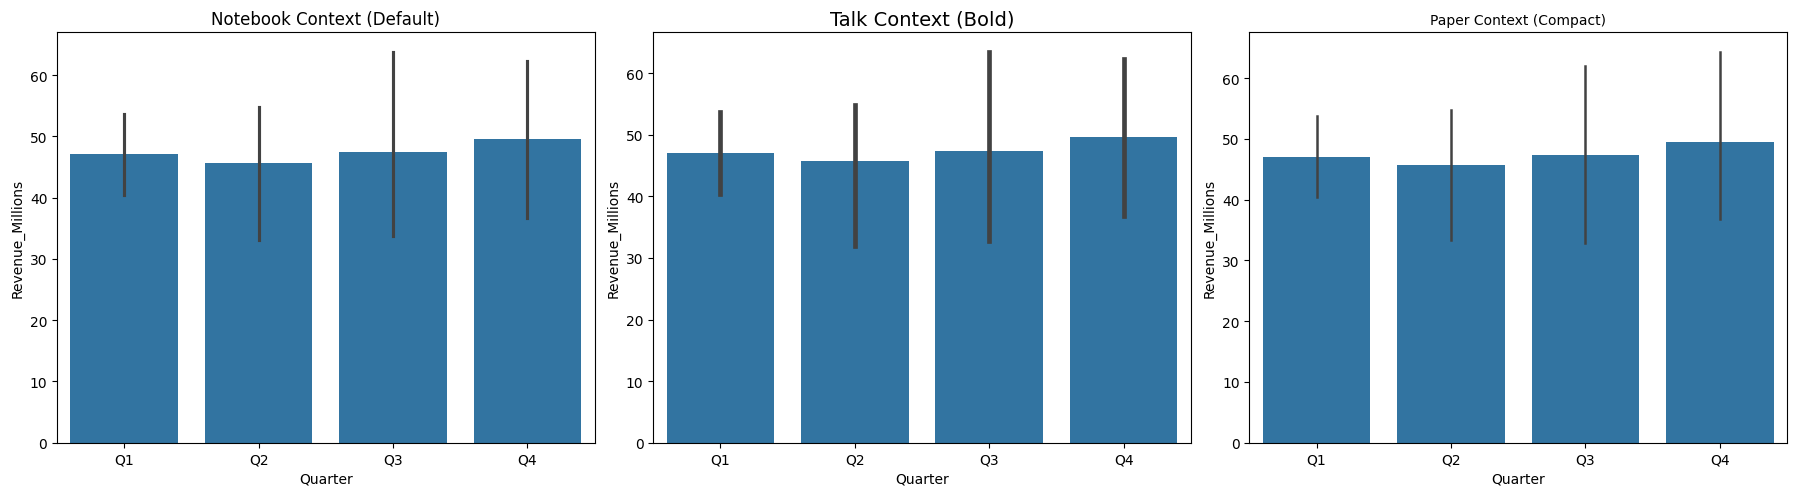

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Create sample revenue data
np.random.seed(42)
data = pd.DataFrame({
    'Quarter': ['Q1', 'Q2', 'Q3', 'Q4'] * 5,
    'Revenue_Millions': np.random.normal(50, 15, 20),
    'Product': np.repeat(['Alpha', 'Beta', 'Gamma', 'Delta', 'Epsilon'], 4)
})
# Create three plots showing different contexts
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
# Default context
sns.set_context("notebook")
sns.barplot(data=data, x='Quarter', y='Revenue_Millions', ax=axes[0])
axes[0].set_title('Notebook Context (Default)', fontsize=12)
# Talk context for executive presentations
sns.set_context("talk", font_scale=1.2)
sns.barplot(data=data, x='Quarter', y='Revenue_Millions', ax=axes[1])
axes[1].set_title('Talk Context (Bold)', fontsize=14)
# Paper context for PDF reports
sns.set_context("paper", font_scale=0.8)
sns.barplot(data=data, x='Quarter', y='Revenue_Millions', ax=axes[2])
axes[2].set_title('Paper Context (Compact)', fontsize=10)
plt.tight_layout()
plt.show()
# Reset to default
sns.set_context("notebook")

# 2. Overlay Distributions with violinplot + swarmplot Combos


/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 35.6% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 39.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 34.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packages/seaborn/categorical.py:3399: UserWarning: 34.8% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


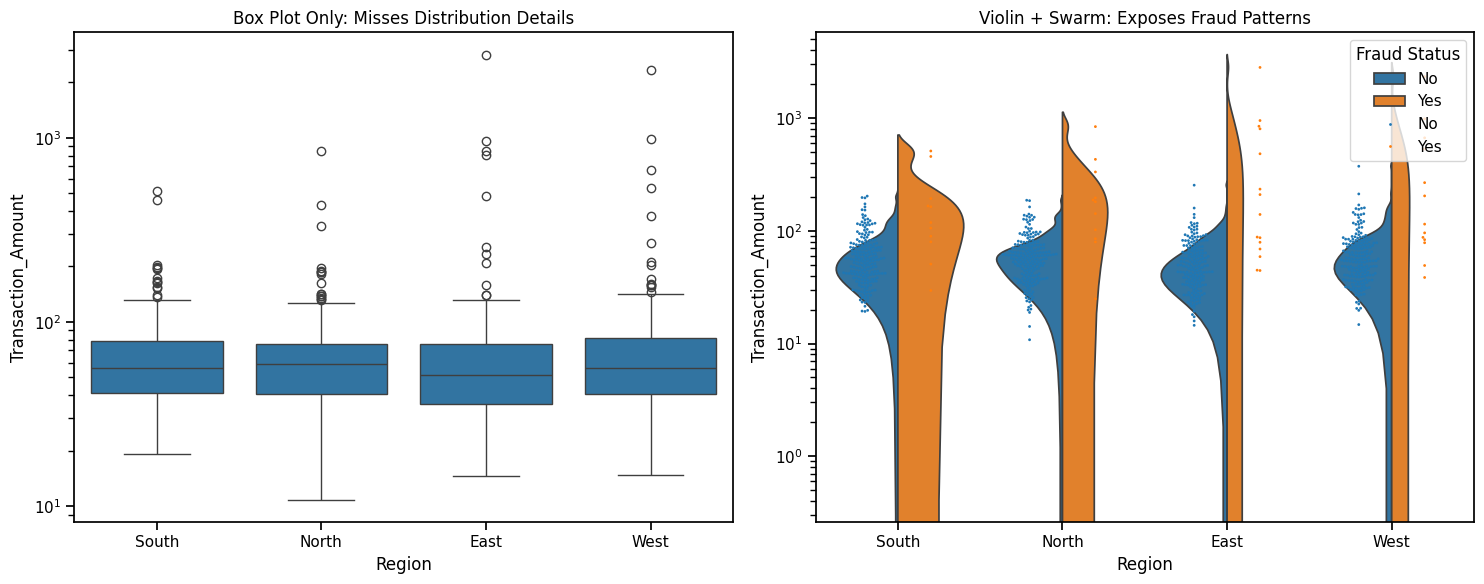

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Simulate fraud detection transaction data
np.random.seed(42)
# Generate legitimate and fraudulent transactions
legitimate = np.random.lognormal(mean=4, sigma=0.5, size=800)
fraudulent = np.random.lognormal(mean=5, sigma=1.2, size=50)
# Combine with region data
df = pd.DataFrame({
    'Transaction_Amount': np.concatenate([legitimate, fraudulent]),
    'Is_Fraud': ['No'] * 800 + ['Yes'] * 50,
    'Region': np.random.choice(['North', 'South', 'East', 'West'], 850)
})
# Create the combined plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
# Left: Basic boxplot (misses patterns)
sns.boxplot(data=df, x='Region', y='Transaction_Amount', ax=ax1)
ax1.set_title('Box Plot Only: Misses Distribution Details')
ax1.set_yscale('log')
# Right: Violin + Swarm reveals outliers
sns.violinplot(data=df, x='Region', y='Transaction_Amount',
               hue='Is_Fraud', split=True, inner=None, ax=ax2)
sns.swarmplot(data=df, x='Region', y='Transaction_Amount',
              hue='Is_Fraud', size=2, dodge=True, ax=ax2)
ax2.set_yscale('log')
ax2.set_title('Violin + Swarm: Exposes Fraud Patterns')
ax2.legend(title='Fraud Status', loc='upper right')
plt.tight_layout()
plt.show()

# 3. Automate Color Consistency with sns.color_palette()


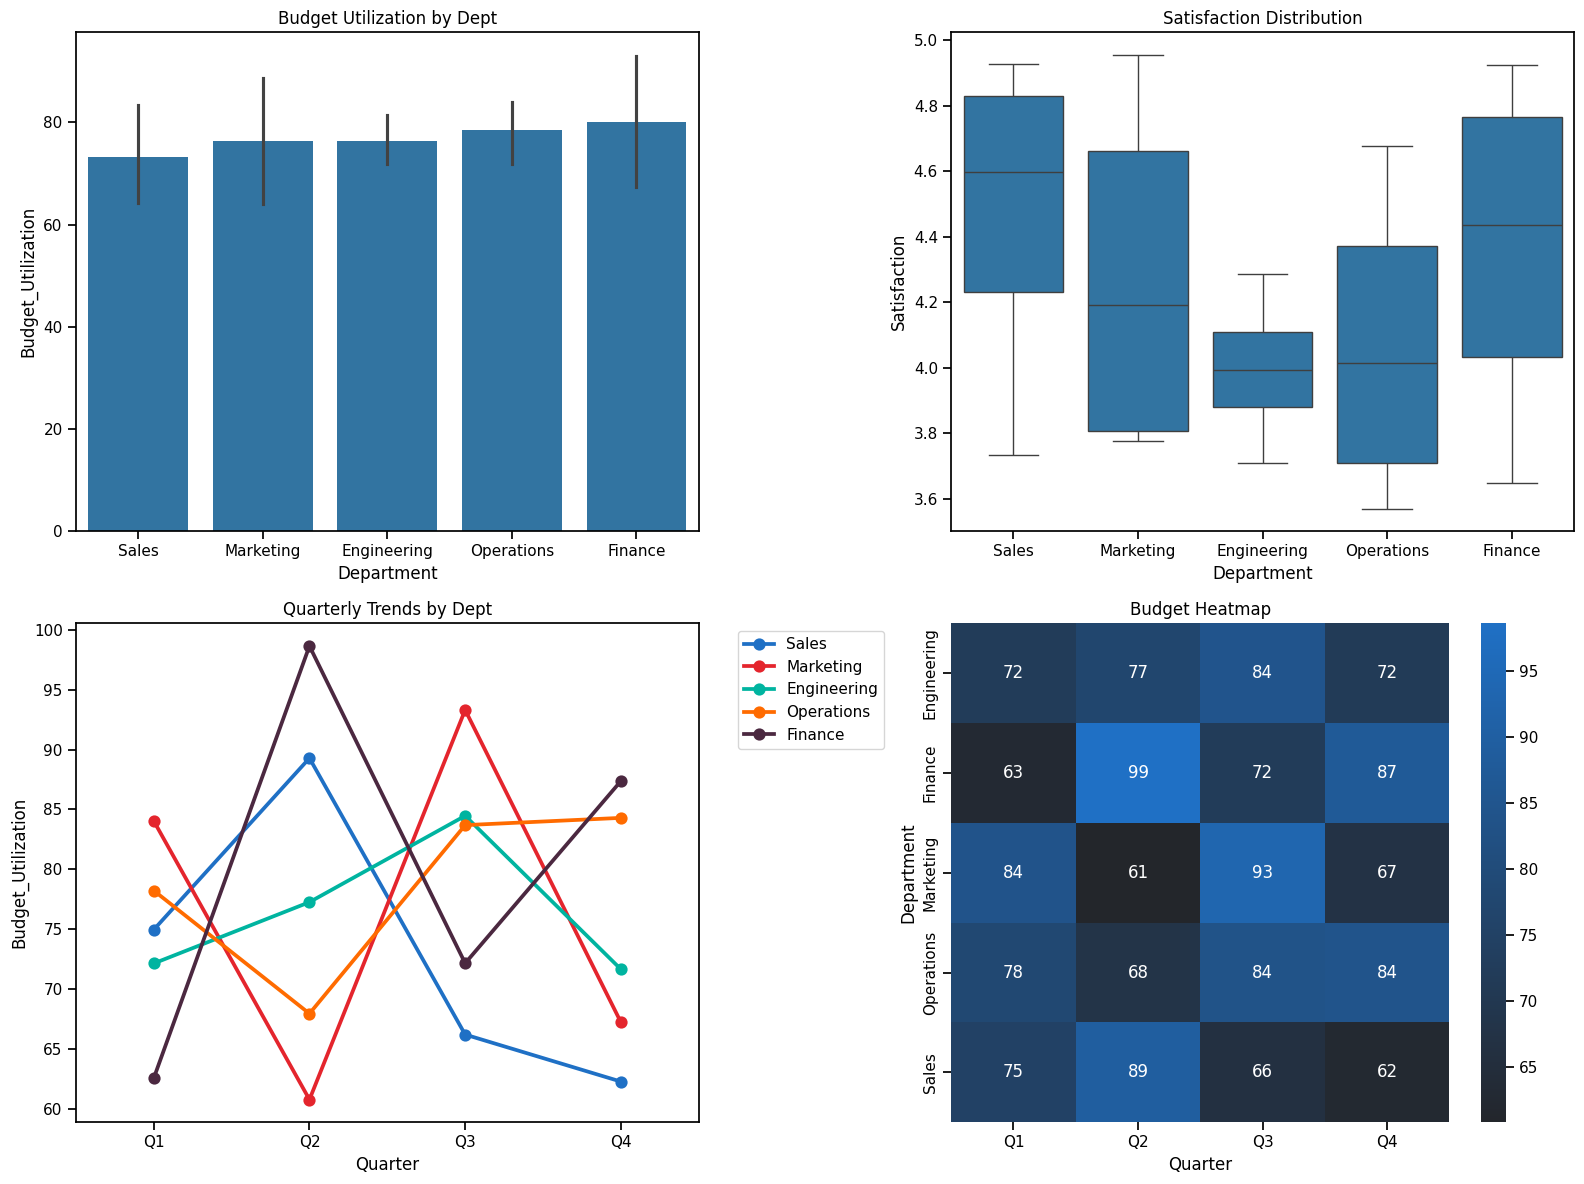

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Define corporate palette (IBM brand colors as example)
corp_palette = sns.color_palette(["#1F70C5", "#E4252D", "#00B4A0", "#FF6B00", "#4B2840"])
# Create sample multi-department data
np.random.seed(42)
departments = ['Sales', 'Marketing', 'Engineering', 'Operations', 'Finance']
quarters = ['Q1', 'Q2', 'Q3', 'Q4']
data = []
for dept in departments:
    for q in quarters:
        data.append({
            'Department': dept,
            'Quarter': q,
            'Budget_Utilization': np.random.uniform(60, 100),
            'Satisfaction': np.random.uniform(3.5, 5.0)
        })
df = pd.DataFrame(data)
# Apply palette across three different chart types
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
# Set palette once
sns.set_palette(corp_palette)
# Chart 1: Bar plot
sns.barplot(data=df, x='Department', y='Budget_Utilization', ax=axes[0,0])
axes[0,0].set_title('Budget Utilization by Dept')
# Chart 2: Box plot
sns.boxplot(data=df, x='Department', y='Satisfaction', ax=axes[0,1])
axes[0,1].set_title('Satisfaction Distribution')
# Chart 3: Point plot
sns.pointplot(data=df, x='Quarter', y='Budget_Utilization',
              hue='Department', ax=axes[1,0])
axes[1,0].set_title('Quarterly Trends by Dept')
axes[1,0].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
# Chart 4: Heatmap
heatmap_data = df.pivot(index='Department', columns='Quarter', values='Budget_Utilization')
sns.heatmap(heatmap_data, annot=True, cmap=sns.dark_palette("#1F70C5", as_cmap=True),
            ax=axes[1,1])
axes[1,1].set_title('Budget Heatmap')
plt.tight_layout()
plt.show()

# 4. Annotate Like a Pro with sns.despine() + ax.annotate()


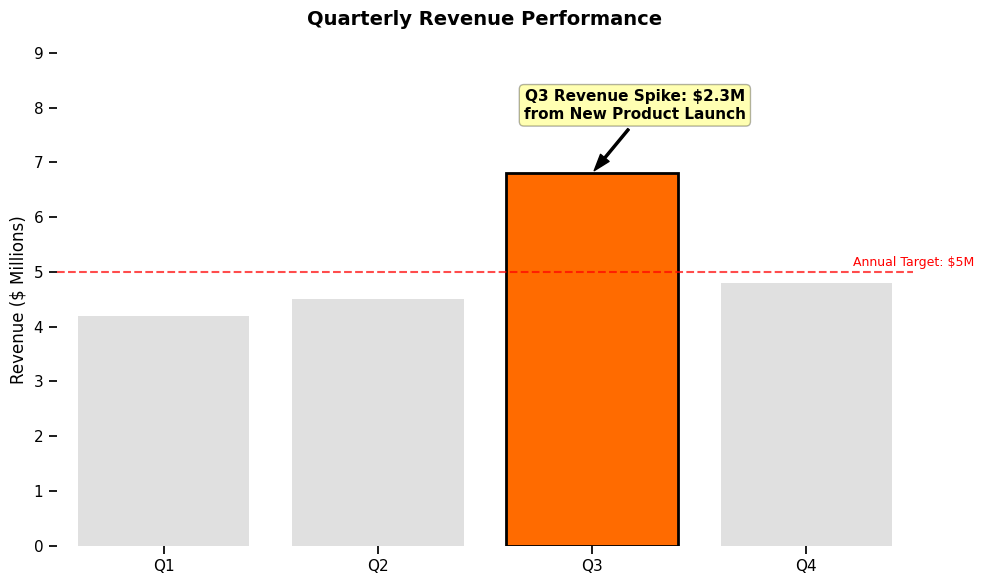

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Create quarterly revenue data with Q3 spike
np.random.seed(42)
quarters = ['Q1', 'Q2', 'Q3', 'Q4']
revenue = [4.2, 4.5, 6.8, 4.8]  # Q3 shows acquisition impact
df = pd.DataFrame({'Quarter': quarters, 'Revenue_Millions': revenue})

# Create plot with professional annotation
fig, ax = plt.subplots(figsize=(10, 6))

# Strip unnecessary spines
sns.despine(left=True, bottom=True)

# Plot with custom styling (Added hue and legend=False to avoid Seaborn warnings)
sns.barplot(data=df, x='Quarter', y='Revenue_Millions',
            hue='Quarter', legend=False,
            palette=['#e0e0e0', '#e0e0e0', '#FF6B00', '#e0e0e0'], ax=ax)

# Highlight Q3 bar
ax.patches[2].set_color('#FF6B00')
ax.patches[2].set_edgecolor('black')
ax.patches[2].set_linewidth(2)

# Professional annotation
ax.annotate("Q3 Revenue Spike: $2.3M\nfrom New Product Launch",
            xy=(2, 6.8), xytext=(2.2, 7.8), # Shifted slightly for better visual balance
            arrowprops=dict(facecolor='black', shrink=0.05, width=1.5, headwidth=8),
            fontsize=11, ha='center', weight='bold',
            bbox=dict(boxstyle="round,pad=0.3", facecolor="yellow", alpha=0.3))

# Add target line
ax.axhline(y=5.0, color='red', linestyle='--', alpha=0.7)
ax.text(3.5, 5.1, 'Annual Target: $5M', fontsize=9, color='red', ha='center')

# Clean labels
ax.set_xlabel('')
ax.set_ylabel('Revenue ($ Millions)', fontsize=12)

# Add Y-axis limit to create headroom for the annotation box
ax.set_ylim(0, 9)

ax.set_title('Quarterly Revenue Performance', fontsize=14, weight='bold', pad=20)

plt.tight_layout()
plt.show()

# 5. Build Interactive-Ready Plots with sns.FacetGrid


/tmp/ipykernel_1645/235388583.py:10: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  quarters = pd.date_range('2023Q1', periods=4, freq='Q')


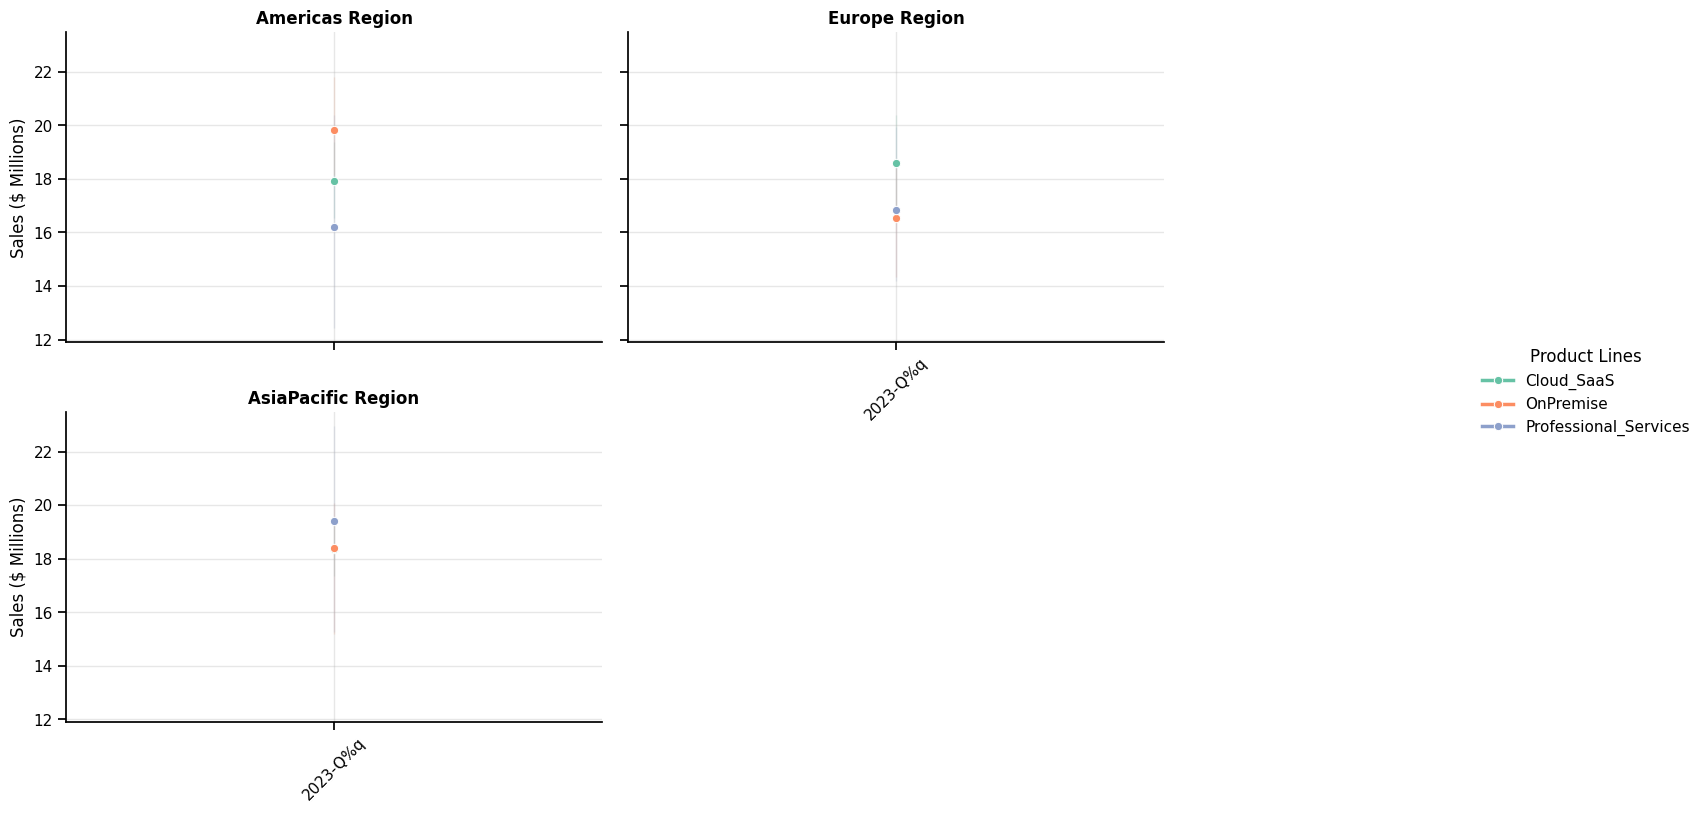

'\nimport plotly.express as px\nfig = px.line(df, x="Quarter", y="Sales_Millions", \n              color="Product", facet_col="Region",\n              title="Interactive Regional Sales Dashboard")\nfig.write_html("interactive_dashboard.html")\n'

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Create multi-region sales data
np.random.seed(42)
regions = ['Americas', 'Europe', 'AsiaPacific']
products = ['Cloud_SaaS', 'OnPremise', 'Professional_Services']
quarters = pd.date_range('2023Q1', periods=4, freq='Q')
data = []
for region in regions:
    for product in products:
        for i, quarter in enumerate(quarters):
            data.append({
                'Region': region,
                'Product': product,
                'Quarter': quarter.strftime('%Y-Q%q'),
                'Sales_Millions': np.random.normal(15 + i*2, 3, 1)[0],
                'Growth_Rate': np.random.uniform(5, 25)
            })
df = pd.DataFrame(data)
# Create FacetGrid for interactive-ready small multiples
g = sns.FacetGrid(df, col="Region", hue="Product",
                  col_wrap=2, height=4, aspect=1.5,
                  palette="Set2")
# Map lineplot function
g.map(sns.lineplot, "Quarter", "Sales_Millions", marker='o', linewidth=2.5)
# Customize each facet
g.set_titles("{col_name} Region", weight='bold', size=12)
g.set_xlabels("")
g.set_ylabels("Sales ($ Millions)")
g.add_legend(title="Product Lines", bbox_to_anchor=(1.05, 0.5), loc='center left')
# Rotate x-axis labels
for ax in g.axes.flat:
    ax.tick_params(axis='x', rotation=45)
    ax.grid(True, alpha=0.3)
# Save as SVG for interactive conversion
plt.savefig('regional_dashboard.svg', format='svg', bbox_inches='tight')
plt.show()
# Conversion code for Plotly (commented as requires plotly installed)
'''
import plotly.express as px
fig = px.line(df, x="Quarter", y="Sales_Millions",
              color="Product", facet_col="Region",
              title="Interactive Regional Sales Dashboard")
fig.write_html("interactive_dashboard.html")
'''

# 6. Dynamic Time Series with sns.lineplot(estimator=None)


/tmp/ipykernel_1645/3116366848.py:8: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  dates = pd.date_range('2024-01-01', periods=100, freq='H')
/tmp/ipykernel_1645/3116366848.py:21: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(data=df, x='Timestamp', y='Sensor_Value',


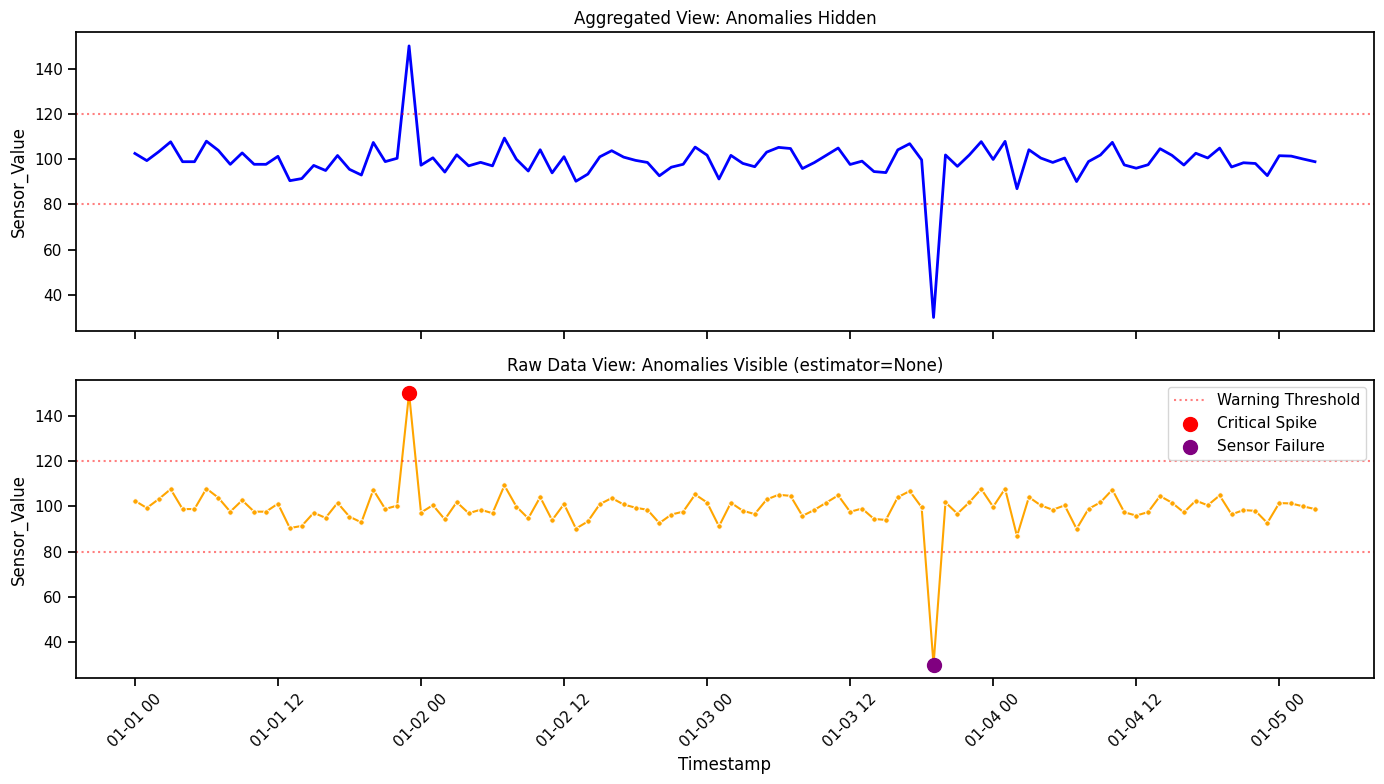

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Simulate IoT sensor data with rare anomalies
np.random.seed(42)
dates = pd.date_range('2024-01-01', periods=100, freq='H')
sensor_readings = np.random.normal(100, 5, 100)
# Inject two anomalies at hours 23 and 67
sensor_readings[23] = 150  # Equipment spike
sensor_readings[67] = 30   # Sensor failure
df = pd.DataFrame({
    'Timestamp': dates,
    'Sensor_Value': sensor_readings,
    'Sensor_ID': ['Device_A'] * 100
})
# Create comparison: aggregated vs raw
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
# Top: Default aggregation hides anomalies
sns.lineplot(data=df, x='Timestamp', y='Sensor_Value',
             estimator='mean', ci=None, ax=ax1, color='blue', linewidth=2)
ax1.set_title('Aggregated View: Anomalies Hidden', fontsize=12)
ax1.axhline(y=120, color='red', linestyle=':', alpha=0.5)
ax1.axhline(y=80, color='red', linestyle=':', alpha=0.5)
# Bottom: Raw data exposes outliers
sns.lineplot(data=df, x='Timestamp', y='Sensor_Value',
             estimator=None, ax=ax2, color='orange', marker='o', markersize=4)
ax2.set_title('Raw Data View: Anomalies Visible (estimator=None)', fontsize=12)
ax2.tick_params(axis='x', rotation=45)
ax2.axhline(y=120, color='red', linestyle=':', alpha=0.5, label='Warning Threshold')
ax2.axhline(y=80, color='red', linestyle=':', alpha=0.5)
ax2.legend()
# Highlight anomalies
ax2.scatter(df.iloc[23]['Timestamp'], sensor_readings[23],
            color='red', s=100, zorder=5, label='Critical Spike')
ax2.scatter(df.iloc[67]['Timestamp'], sensor_readings[67],
            color='purple', s=100, zorder=5, label='Sensor Failure')
ax2.legend()
plt.tight_layout()

# 7. Heatmaps That Tell Stories with sns.heatmap(annot_kws={"fontsize": 14})


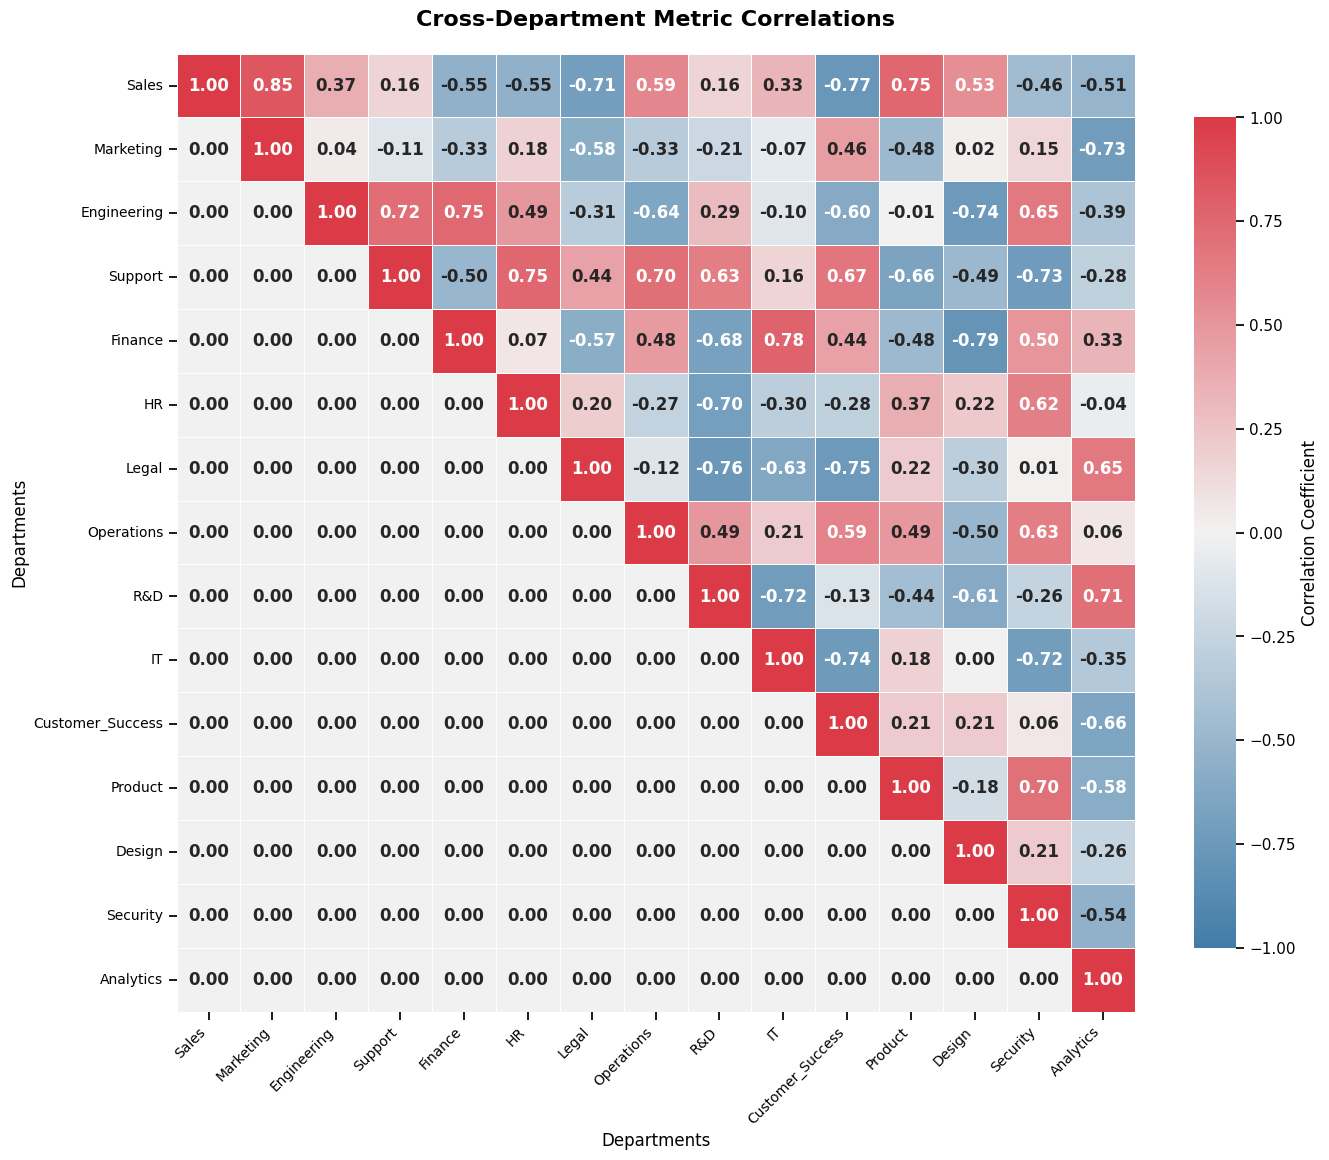

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Create enterprise correlation matrix (15 departments)
np.random.seed(42)
departments = ['Sales', 'Marketing', 'Engineering', 'Support', 'Finance',
               'HR', 'Legal', 'Operations', 'R&D', 'IT',
               'Customer_Success', 'Product', 'Design', 'Security', 'Analytics']
# Generate realistic correlation data
n = len(departments)
correlation_matrix = np.random.uniform(-0.8, 0.8, (n, n))
np.fill_diagonal(correlation_matrix, 1.0)
correlation_matrix = np.triu(correlation_matrix)  # Upper triangle only
# Make some values significant
correlation_matrix[0, 1] = 0.85  # Sales-Marketing strong positive
correlation_matrix[8, 9] = -0.72  # R&D-IT negative correlation
df_corr = pd.DataFrame(correlation_matrix, index=departments, columns=departments)
# Professional heatmap configuration
fig, ax = plt.subplots(figsize=(14, 12))
# Create diverging palette
cmap = sns.diverging_palette(240, 10, as_cmap=True, center="light")
# Heatmap with large annotations
sns.heatmap(df_corr,
            annot=True,
            fmt='.2f',
            center=0,
            cmap=cmap,
            vmin=-1, vmax=1,
            square=True,
            annot_kws={"fontsize": 12, "weight": "bold"},
            cbar_kws={"shrink": 0.8, "label": "Correlation Coefficient"},
            linewidths=0.5,
            ax=ax)
# Styling
ax.set_title('Cross-Department Metric Correlations',
             fontsize=16, weight='bold', pad=20)
ax.set_xlabel('Departments', fontsize=12)
ax.set_ylabel('Departments', fontsize=12)
# Rotate labels
plt.setp(ax.get_xticklabels(), rotation=45, ha='right', fontsize=10)
plt.setp(ax.get_yticklabels(), rotation=0, ha='right', fontsize=10)
plt.tight_layout()
plt.show()

# 8. Small Multiples for Storytelling with sns.relplot(kind="line")


/tmp/ipykernel_1645/3886399354.py:9: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  months = pd.date_range('2023-01-01', periods=12, freq='M')


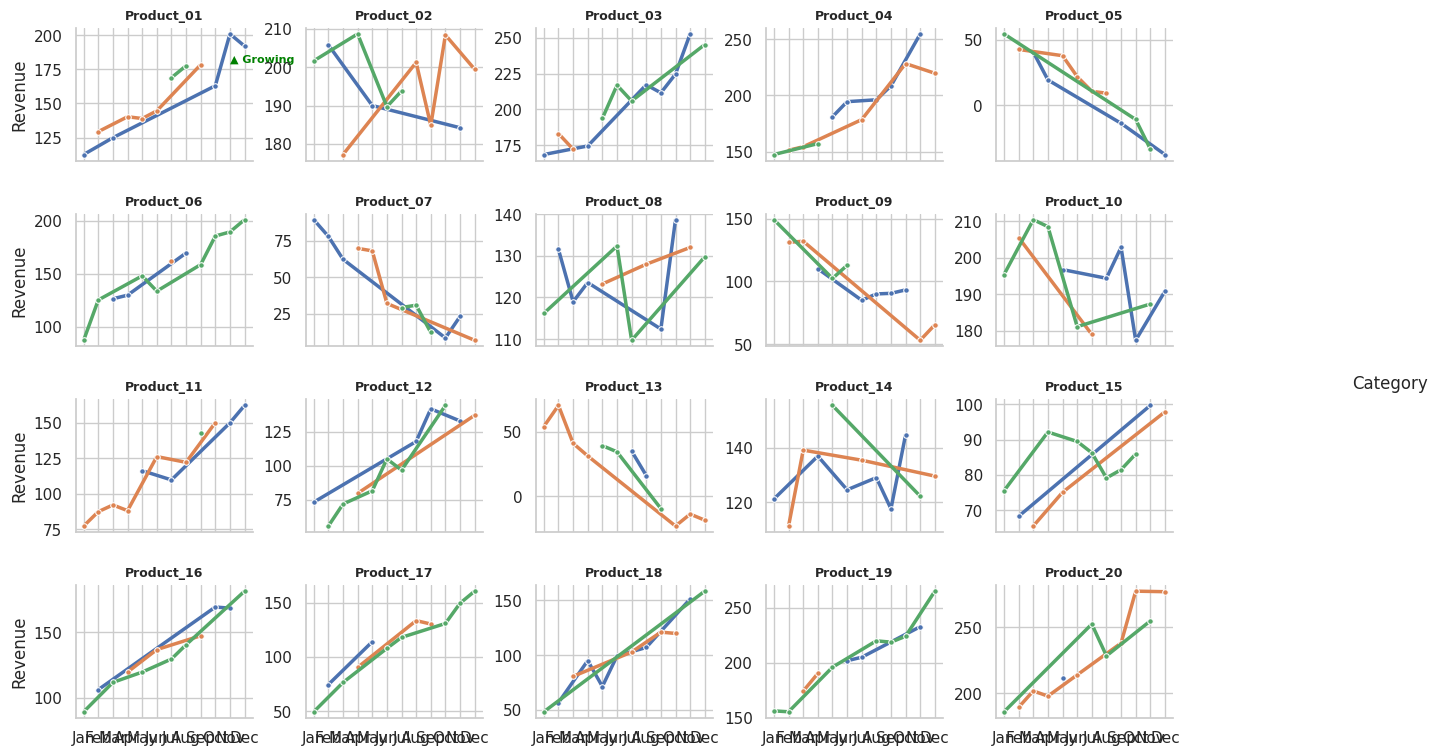

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Create 20 product lines across 12 months
np.random.seed(42)
products = [f'Product_{i:02d}' for i in range(1, 21)]
months = pd.date_range('2023-01-01', periods=12, freq='M')
data = []
for product in products:
    base_revenue = np.random.uniform(50, 200)
    trend = np.random.choice([-1, 0, 1], p=[0.2, 0.3, 0.5])

    for i, month in enumerate(months):
        data.append({
            'Product': product,
            'Month': month.strftime('%b'),
            'Revenue': base_revenue + (trend * i * 8) + np.random.normal(0, 10),
            'Category': np.random.choice(['A', 'B', 'C'])
        })
df = pd.DataFrame(data)

# Create magazine-quality small multiples
sns.set_style("whitegrid")
g = sns.relplot(
    data=df,
    x='Month',
    y='Revenue',
    kind='line',
    col='Product',
    hue='Category',
    col_wrap=5,  # 4 rows x 5 columns = 20 products
    height=2,
    aspect=1.2,
    palette='deep',
    linewidth=2.5,
    marker='o',
    markersize=4,
    facet_kws={'sharex': True, 'sharey': False},
    legend=False
)

# Professional styling
g.set_titles("{col_name}", size=9, weight='bold')
g.set_axis_labels("", "Revenue")

# Now this creates exactly ONE legend without overlapping
g.add_legend(title='Category', bbox_to_anchor=(1.05, 0.5), loc='center left')

# Add trend arrows to top performers
g.axes[0].annotate("▲ Growing", xy=(10, 180), fontsize=8, color='green', weight='bold')
g.axes[19].annotate("▼ Declining", xy=(10, 60), fontsize=8, color='red', weight='bold')

plt.subplots_adjust(hspace=0.4, wspace=0.3)
plt.show()

# 9. Benchmark Against Goals: ax.axhline() + sns.barplot()


/tmp/ipykernel_1645/1320487150.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Team', y='Actual_Sales', palette=colors, ax=ax)


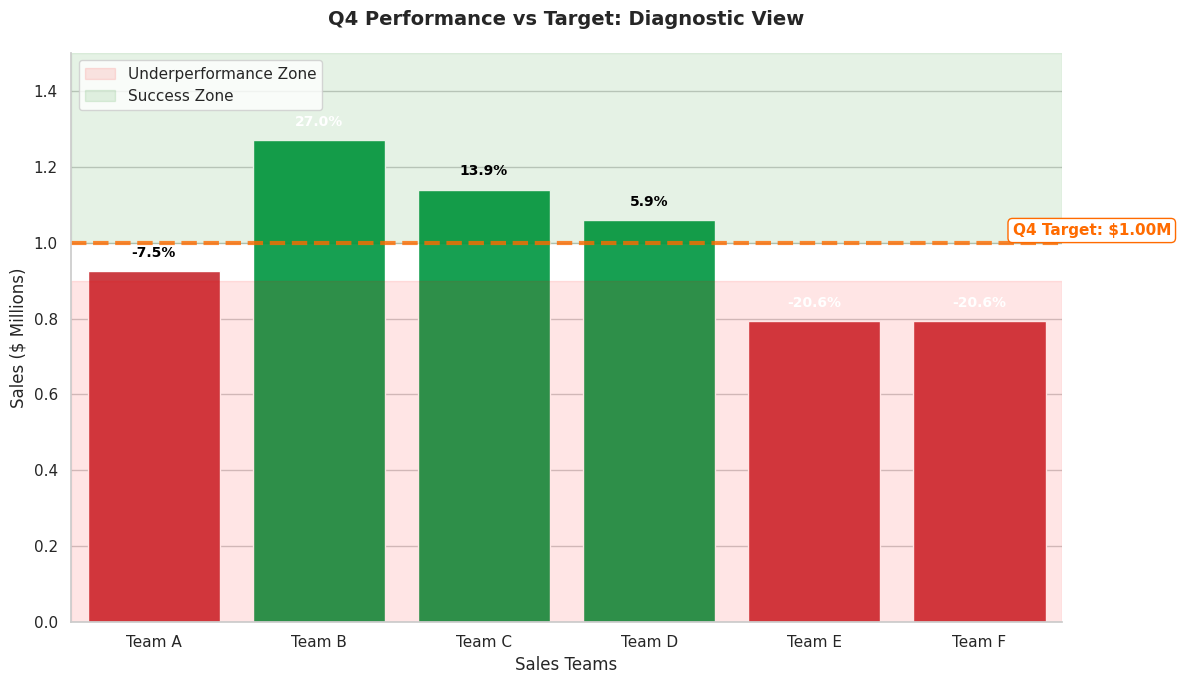

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Create team performance vs target data
np.random.seed(42)
teams = ['Team_A', 'Team_B', 'Team_C', 'Team_D', 'Team_E', 'Team_F']
target_millions = 1.0  # $1M target
data = []
for team in teams:
    actual_sales = np.random.uniform(0.7, 1.3)
    data.append({
        'Team': team.replace('_', ' '),
        'Actual_Sales': actual_sales,
        'Target': target_millions,
        'Performance': (actual_sales / target_millions - 1) * 100
    })
df = pd.DataFrame(data)
# Create diagnostic bar chart with target line
fig, ax = plt.subplots(figsize=(12, 7))
# Base bar plot with conditional colors
colors = ['#00B74F' if x >= target_millions else '#E4252D' for x in df['Actual_Sales']]
sns.barplot(data=df, x='Team', y='Actual_Sales', palette=colors, ax=ax)
# Critical target benchmark line
ax.axhline(y=target_millions, color='#FF6B00', linestyle='--', linewidth=3, alpha=0.8)
ax.text(5.2, target_millions + 0.02, 'Q4 Target: $1.00M',
        fontsize=11, weight='bold', color='#FF6B00',
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor='#FF6B00'))
# Add performance labels on bars
for i, row in df.iterrows():
    performance_text = f"{row['Performance']:.1f}%"
    ax.text(i, row['Actual_Sales'] + 0.03, performance_text,
            ha='center', va='bottom', fontsize=10, weight='bold',
            color='black' if abs(row['Performance']) < 20 else 'white')
# Styling
sns.despine(top=True, right=True)
ax.set_xlabel('Sales Teams', fontsize=12)
ax.set_ylabel('Sales ($ Millions)', fontsize=12)
ax.set_title('Q4 Performance vs Target: Diagnostic View',
             fontsize=14, weight='bold', pad=20)
ax.set_ylim(0, 1.5)
# Add performance zones
ax.axhspan(0, 0.9, alpha=0.1, color='red', label='Underperformance Zone')
ax.axhspan(1.0, 1.5, alpha=0.1, color='green', label='Success Zone')
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

# 10. The Boardroom Secret: sns.dark_palette() for Projector Demos


Text(0.5, 0.98, 'Q4 2024 Executive Summary')

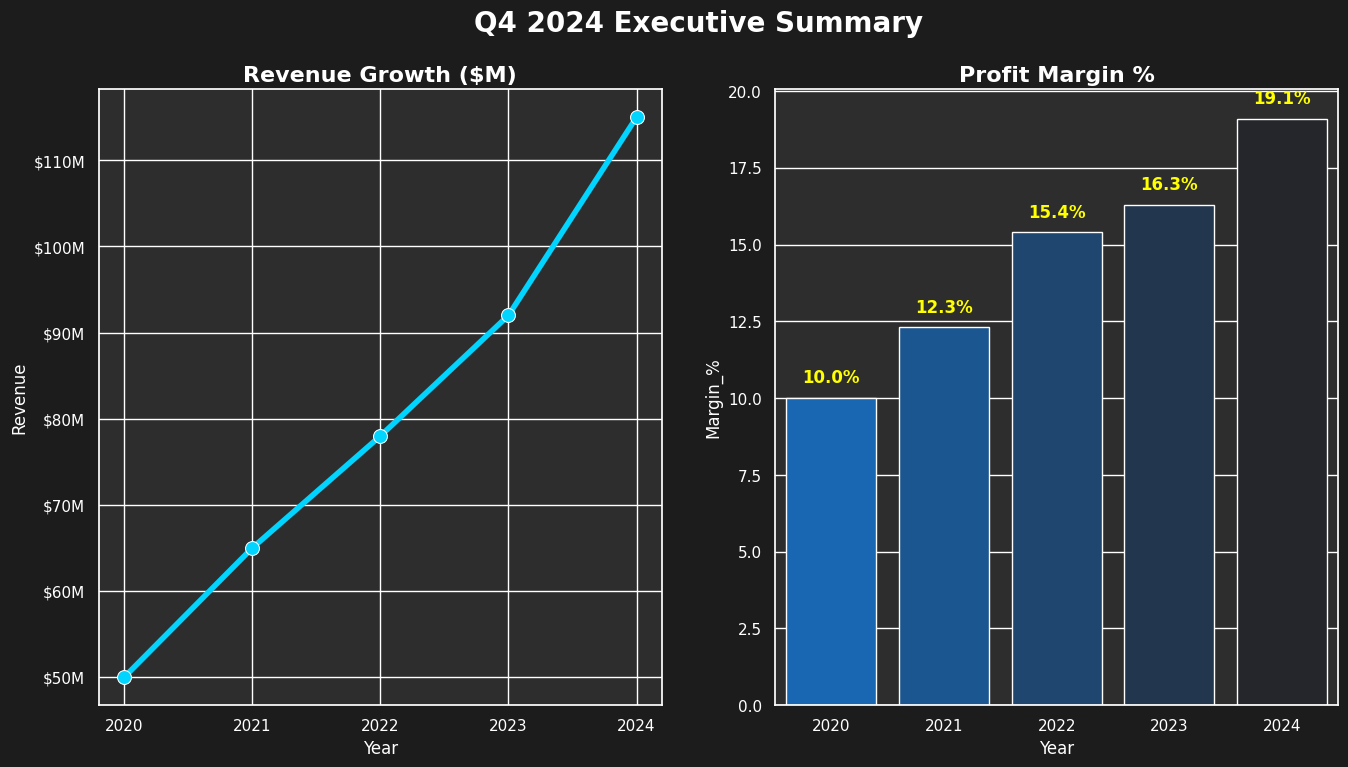

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Enable dark background for projector readiness
plt.style.use("dark_background")

# Create corporate growth data
np.random.seed(42)
years = ['2020', '2021', '2022', '2023', '2024']
metrics = ['Revenue', 'Profit', 'Margin_%', 'Employees']
data = pd.DataFrame({
    'Year': years,
    'Revenue': np.array([50, 65, 78, 92, 115]) * 1e6,
    'Profit': np.array([5, 8, 12, 15, 22]) * 1e6,
    'Margin_%': [10, 12.3, 15.4, 16.3, 19.1],
    'Employees': [500, 620, 750, 890, 1100]
})

# Create dark-themed dashboard
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))
fig.patch.set_facecolor('#1C1C1C')  # Deep charcoal background

# Left: Revenue trend with dark palette
sns.lineplot(data=data, x='Year', y='Revenue', ax=ax1,
             color='#00D4FF', linewidth=4, marker='o', markersize=10)
ax1.set_facecolor('#2D2D2D')
ax1.tick_params(colors='white')
ax1.xaxis.label.set_color('white')
ax1.yaxis.label.set_color('white')
ax1.title.set_color('white')
ax1.set_title('Revenue Growth ($M)', fontsize=16, weight='bold')

# Format y-axis in millions
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1e6:.0f}M'))

# Right: Margin bar chart using dark palette
dark_blue_palette = sns.dark_palette("#0066CC", n_colors=len(data), reverse=True)

sns.barplot(data=data, x='Year', y='Margin_%', ax=ax2,
            hue='Year', legend=False, palette=dark_blue_palette)

ax2.set_facecolor('#2D2D2D')
ax2.tick_params(colors='white')
ax2.set_title('Profit Margin %', fontsize=16, weight='bold')

# High-contrast text annotations
for i, v in enumerate(data['Margin_%']):
    ax2.text(i, v + 0.5, f'{v:.1f}%', ha='center',
             fontsize=12, weight='bold', color='yellow')

# Professional title slide
fig.suptitle('Q4 2024 Executive Summary',
             fontsize=20, weight='bold', color='white')